## Predicting the Solubility Class of a molecule using its Morgan fingerprints

#### Notebook Overview

This notebook demonstrates the application of **Multi-Layer Perceptrons (MLPs)** for predicting the **Solubility Class** of organic compounds. Instead of using simple descriptors, we will use **Morgan fingerprints** to capture deeper structural patterns for classification.

**Learning Objectives:**
- Convert SMILES strings into **Morgan fingerprints** (circular structural representations)
- Build a custom PyTorch Dataset for fingerprint data
- Design and train a Multi-Layer Perceptron (MLP) for binary classification
- Evaluate classification performance using Accuracy and Confusion Matrices

---

**Task:** Classification - Predict whether a molecule is highly soluble or poorly soluble based on a LogS cutoff.

**Why Morgan Fingerprints:** 
- Instead of relying on a few predefined descriptors (like MolWt), Morgan fingerprints encode the specific local environments around each atom into a binary bit string, capturing rich structural motifs crucial for drug discovery.

## Setting up the notebook and importing necessary libraries

In [ ]:
!pip install rdkit

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
import requests
from io import StringIO

warnings.filterwarnings('ignore')

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Chemistry
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem


## Loading and Analyzing ESol dataset

In [3]:
def load_esol_dataset():
    """Load the ESOL (Delaney) solubility dataset"""
    url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
    response = requests.get(url)
    response.raise_for_status()

    df = pd.read_csv(StringIO(response.text))
    print(f"Loaded ESOL with {len(df)} compounds")
    print("Columns in dataset:", df.columns.tolist())
    df = df[['smiles', 'measured log solubility in mols per litre']]
    df.columns = ['SMILES', 'LogS']

    # Remove invalid SMILES
    valid_smiles = []
    for smiles in df['SMILES']:
        mol = Chem.MolFromSmiles(smiles)
        valid_smiles.append(mol is not None)

    df = df[valid_smiles].reset_index(drop=True)

    return df

# Load dataset
df = load_esol_dataset()

CUTOFF = -2.0  # Example cutoff for solubility classification
df['SolubilityClass'] = np.where(df['LogS'] < CUTOFF, 0, 1)

Loaded ESOL with 1128 compounds
Columns in dataset: ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']


Plotting the distribution of $logS$ values

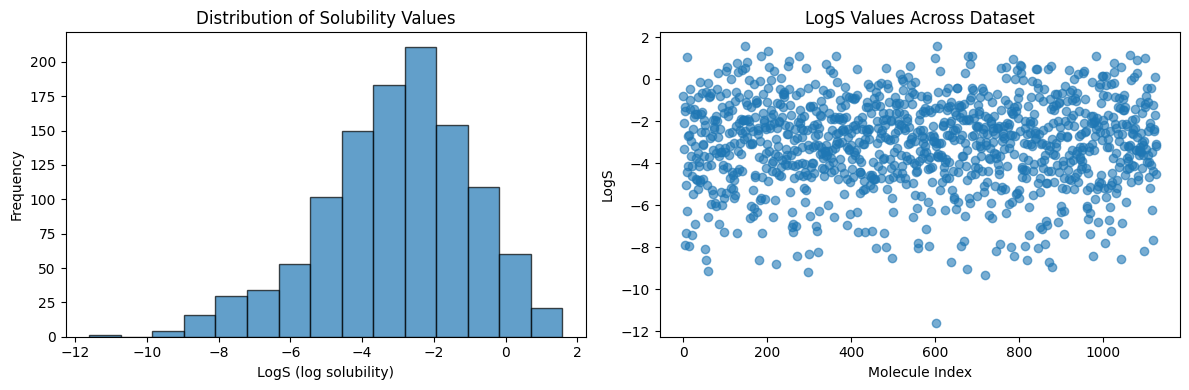

In [4]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['LogS'], bins=15, alpha=0.7, edgecolor='black')
plt.xlabel('LogS (log solubility)')
plt.ylabel('Frequency')
plt.title('Distribution of Solubility Values')

plt.subplot(1, 2, 2)
plt.scatter(range(len(df)), df['LogS'], alpha=0.6)
plt.xlabel('Molecule Index')
plt.ylabel('LogS')
plt.title('LogS Values Across Dataset')
plt.tight_layout()
plt.show()

Plotting the distribution of $logP$ values

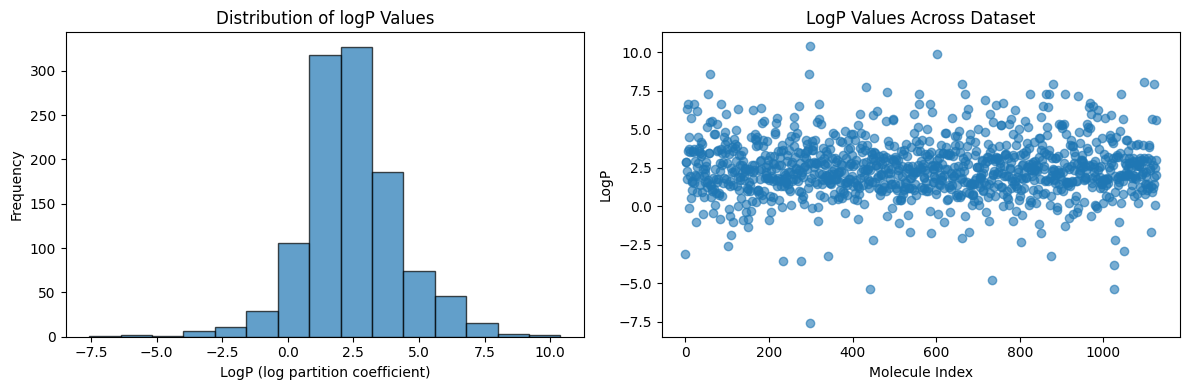

In [5]:
logp_values =[]
for smile in df['SMILES']:
    mol = Chem.MolFromSmiles(smile)
    if mol:
        logp = Descriptors.MolLogP(mol)
        logp_values.append(logp)
    else:
        logp_values.append(np.nan)
logp_values = np.array(logp_values)
df['LogP'] = logp_values

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['LogP'], bins=15, alpha=0.7, edgecolor='black')
plt.xlabel('LogP (log partition coefficient)')
plt.ylabel('Frequency')
plt.title('Distribution of logP Values')

plt.subplot(1, 2, 2)
plt.scatter(range(len(df)), df['LogP'], alpha=0.6)
plt.xlabel('Molecule Index')
plt.ylabel('LogP')
plt.title('LogP Values Across Dataset')
plt.tight_layout()
plt.show()

## Setting Hyperparameters and Generating Fingerprints

In [6]:
FINGERPRINT_SIZE = 2048
MAX_RADIUS = 3
BATCH_SIZE = 1
NUM_EPOCHS = 100
WEIGHT_DECAY = 1e-3
LEARNING_RATE = 1e-3
PATIENCE = 3
FACTOR = 0.5
EARLY_STOPPING = 10
DROPOUT = 0.2

Generating Morgan fingerprints with the help of RDkit. Morgan fingerprints are computational tools in chemistry that represent molecules as binary bit strings, encoding structural features by identifying circular substructures (paths) around each atom up to a set radius, then hashing these unique environments into a fixed-length vector.

In [7]:
fingerprints = []

for smile in df["SMILES"]:
    mol = Chem.MolFromSmiles(smile)
    fpgen = AllChem.GetMorganGenerator(fpSize=FINGERPRINT_SIZE, radius=MAX_RADIUS)
    morganfp = np.array(fpgen.GetFingerprint(mol))
    fingerprints.append(morganfp)

df["morgan"] = fingerprints

### How the hyperparameters matter?

If the `FINGERPRINT_SIZE` is large, more substructures can be encoded with less collisions, but if the `FINGERPRINT_SIZE` is less, collisions are more likely, but the model is smaller because it has lesser number of parameters. A smaller model is faster. Therefore, we will have to trade off between speed and accuracy.

`MAX_RADIUS` also affects the model in a similar manner. Play around with the hyperparameters to see how the performance changes.

## 3. Data Preparation for PyTorch

In [8]:
class FPDataset(Dataset):
    def __init__(self,x,y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, index):
        return self.x[index],self.y[index]
    
X_train, X_test, y_train, y_test = train_test_split(
    df['morgan'].values, df['SolubilityClass'].values, # as we are predicting the SolubilityClass
    test_size=0.2, random_state=42
)

train_dataset = FPDataset(X_train,y_train)
test_dataset = FPDataset(X_test,y_test)
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle = False)

## 4. Multi-Layer Perceptron (MLP) Architecture

### 4.1 Defining the Model
We define our MLP using PyTorch's `nn.Module`. Our network consists of:
- **Input Layer**: Takes in the Morgan fingerprint of size `FINGERPRINT_SIZE`.
- **Hidden Layers**: Two fully connected (`nn.Linear`) layers with `ReLU` (Rectified Linear Unit) activations to introduce non-linearity.
- **Dropout Layers**: Randomly drops connections during training to prevent **overfitting**.
- **Output Layer**: A final linear layer that outputs a single logit representing the prediction for our binary class.

### 4.2 Loss Function, Optimizer, and Learning Rate Scheduler

In [9]:
class MLP(nn.Module):
    def __init__(self,input_channels=2048):
        super(MLP, self).__init__()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_channels,100), #hidden layer 1
            nn.ReLU(),
            nn.Dropout(DROPOUT), #dropout for regularisation
            nn.Linear(100,50), #hidden layer 2
            nn.ReLU(),
            nn.Dropout(DROPOUT), #dropout for regularisation
            nn.Linear(50, 1),
            nn.Sigmoid()
        )
    def forward(self,x):
        y = self.classifier(x)
        return y

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLP(input_channels=FINGERPRINT_SIZE).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY) #weight decay for regularisation
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=PATIENCE, factor=FACTOR) #reduce learning rate by 0.5 if validation loss does not improve for 3 epochs


## 5. Training the Classification Model

### 5.1 The Training Loop
Training a neural network involves looping over the dataset for multiple **epochs**. In each epoch, the model performs the following steps for each batch:
1. **Forward Pass**: Passes the input fingerprints through the network to get predictions.
2. **Compute Loss**: Compares predictions against true labels using the chosen criterion.
3. **Backward Pass (`loss.backward()`)**: Calculates the gradients of the loss with respect to every model weight using backpropagation.
4. **Update Weights (`optimizer.step()`)**: Adjusts the weights to minimize the loss.

### 5.2 Evaluation and Early Stopping
After training on all batches in an epoch, the model switches to `eval()` mode. We calculate the loss on the **Test Set** to monitor its generalization. 
If the test loss fails to improve for a set number of epochs (`EARLY_STOPPING`), we stop training early, to prevent the model from memorizing the training data (overfitting).

In [11]:
def train_model(model,train_loader,test_loader,num_epochs=NUM_EPOCHS):
    train_losses = [] #list to store training losses

    all_predictions = [] #list to store predictions
    all_logs = [] #list to store true values

    test_losses = [] #list to store test losses

    early_stopping_counter = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for fp, logs in tqdm(train_loader,desc="training"):
            logs = logs.float().to(device)
            fp = fp.float().to(device)

            optimizer.zero_grad() # Zero the gradients,or else they will keep accumulating
            outputs = model(fp)

            loss = criterion(outputs, logs.unsqueeze(1))
            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        model.eval() #disables dropout and other regularization

        test_loss = 0.0

        all_predictions = []
        all_logs = []

        with torch.no_grad():
            for fp,logs in tqdm(test_loader,desc="testing"):
                logs = logs.float().to(device)
                fp = fp.float().to(device)
                outputs = model(fp)

                loss = criterion(outputs, logs.unsqueeze(1))  # Classification loss
                test_loss += loss.item()

                all_predictions.extend(outputs.cpu().numpy())
                all_logs.extend(logs.cpu().numpy())

            test_loss = test_loss / len(test_loader)

            scheduler.step(test_loss)

            if(epoch>0):
                if test_loss > test_losses[-1]:  # Check if the test loss has increased
                    early_stopping_counter += 1
                elif abs(test_loss - test_losses[-1]) < 1e-4:  # Check if the test loss has not changed significantly
                    early_stopping_counter += 1
                else:
                    early_stopping_counter = 0
                
            if early_stopping_counter >= EARLY_STOPPING:
                break
            
            train_losses.append(train_loss)
            test_losses.append(test_loss)

            print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.4f}, '
              f'Test Loss: {test_loss:.4f},')
    return train_losses, test_losses


In [12]:
train_losses, test_losses = train_model(model,train_loader,test_loader,100)

testing: 100%|██████████| 226/226 [00:00<00:00, 718.26it/s]


Epoch [1/100], Train Loss: 0.6908, Test Loss: 0.6669,


testing: 100%|██████████| 226/226 [00:00<00:00, 904.09it/s]


Epoch [2/100], Train Loss: 0.6470, Test Loss: 0.6514,


testing: 100%|██████████| 226/226 [00:00<00:00, 872.18it/s]


...

testing: 100%|██████████| 226/226 [00:00<00:00, 659.51it/s]


Epoch [56/100], Train Loss: 0.5813, Test Loss: 0.6458,


testing: 100%|██████████| 226/226 [00:00<00:00, 990.63it/s] 


Epoch [57/100], Train Loss: 0.5808, Test Loss: 0.6458,


testing: 100%|██████████| 226/226 [00:00<00:00, 1061.04it/s]


## 6. Model Evaluation and Performance Analysis

### 6.1 Learning Curves
Visualizing the training and test losses across epochs helps us diagnose model behavior:
- **Underfitting**: Both training and test losses are high.
- **Overfitting**: Training loss decreases, but test loss starts to increase.
- **Good Fit**: Both losses decrease and stabilize close to each other.

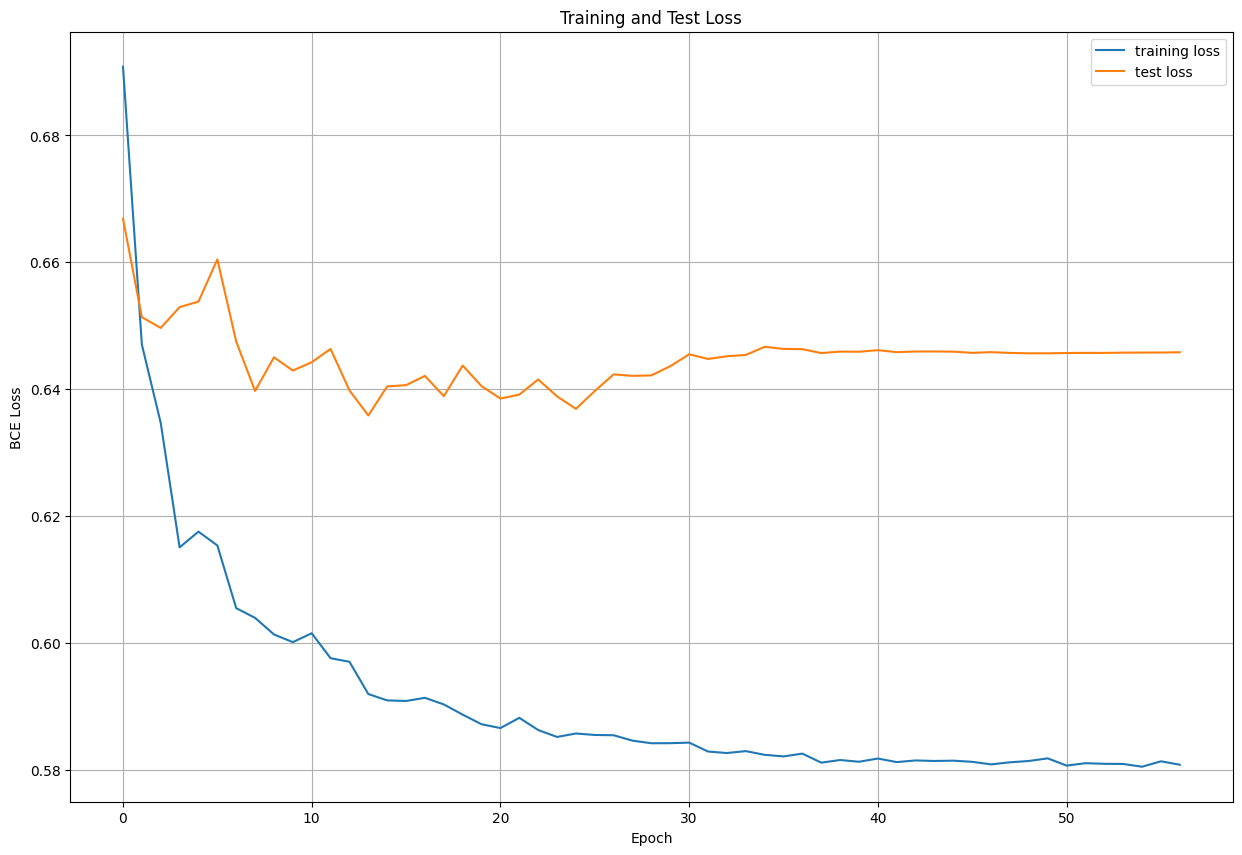

In [13]:
plt.figure(figsize=(15, 10))
plt.plot(train_losses,label="training loss")
plt.plot(test_losses,label = "test loss")
plt.title('Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True)

### 6.2 Accuracy and Confusion Matrix

To properly evaluate a classification model, we use:
- **Accuracy**: The percentage of correctly predicted classes out of the total predictions.
- **Confusion Matrix**: A table that visualizes the performance of our algorithm. It shows:
    - **True Positives & True Negatives**: Correct predictions (the diagonal).
    - **False Positives & False Negatives**: Incorrect predictions (the off-diagonal).

Let's evaluate the model on the test set and plot these metrics.

evaluating: 100%|██████████| 226/226 [00:00<00:00, 973.94it/s]


Accuracy on test set: 0.8363


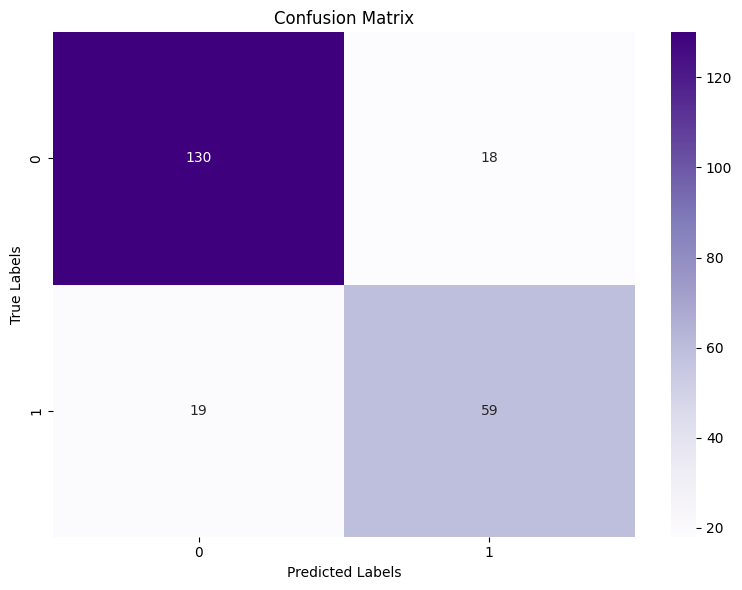

In [14]:
preds = []
targets = []

model.eval()
with torch.no_grad():
    for fp, logs in tqdm(test_loader, desc="evaluating"):
        logs = logs.float().to(device)
        fp = fp.float().to(device)
        outputs = model(fp)

        preds.extend(outputs.cpu().numpy())
        targets.extend(logs.cpu().numpy())
preds = np.array(preds).flatten()
targets = np.array(targets).flatten()

predicted_classes = (preds >= 0.5).astype(int)
accuracy = np.mean(predicted_classes == targets)
print(f'Accuracy on test set: {accuracy:.4f}')

cm = confusion_matrix(targets, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Exercise: MLP Regression with MACCS Fingerprints

In the previous sections, we trained a Multi-Layer Perceptron (MLP) for **Classification** using **Morgan** fingerprints. Now, your task is to build a **Regression** model using **MACCS** fingerprints.

**Task Description:**
1. **Generate MACCS Fingerprints:** Use RDKit's `MACCSkeys.GenMACCSKeys` to calculate MACCS fingerprints for each SMILES string.
2. **Create Target Values:** Use the raw LogS values as your continuous target labels.
3. **Define Model Architecture:** Modify the MLP architecture. For regression, you should output a single continuous value without a sigmoid activation at the end.
4. **Train and Evaluate:** Implement the training loop using `MSELoss` as the criterion and `optim.Adam` as the optimizer. Finally, calculate the test R-squared score or MSE.

In [ ]:
from rdkit.Chem import MACCSkeys
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Task 1: Generate MACCS Fingerprints
def generate_maccs_fps(smiles_list):
    fingerprints = []
    # YOUR CODE HERE
    return fingerprints

# Task 2: Define the PyTorch Dataset and DataLoaders
# Assuming you have your continuous targets ready (e.g., LogS values)
# YOUR CODE HERE

# Task 3: Define the MLP Architecture for Regression
class MLPRegressor(nn.Module):
    def __init__(self, input_channels=167):
        super(MLPRegressor, self).__init__()
        # YOUR CODE HERE 
        # Example:
        # self.model = nn.Sequential(
        #     nn.Linear(input_channels, 100),
        #     nn.ReLU(),
        #     nn.Linear(100, 1)
        # )
        pass
        
    def forward(self, x):
        # YOUR CODE HERE
        pass

# Task 4: Train and Evaluate
def train_and_evaluate_mlp_regressor(model, train_loader, test_loader, epochs=10):
    # criterion = nn.MSELoss()
    # optimizer = optim.Adam(model.parameters(), lr=1e-3)
    # YOUR CODE HERE
    pass
